In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [5]:
df = pd.read_csv("/content/datos_tratados.csv")

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_bin,PaperlessBilling_bin
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,0,1
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0,0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1,1
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1,1
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1,1


#Eliminación de Columnas Irrelevantes

In [6]:
# Se copia el dataframe original y se eliminan columnas irrelevantes
df_ml = df.copy()
df_ml.drop(columns=["customerID", "Churn"], inplace=True)

df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer.gender            7043 non-null   object 
 1   customer.SeniorCitizen     7043 non-null   int64  
 2   customer.Partner           7043 non-null   object 
 3   customer.Dependents        7043 non-null   object 
 4   customer.tenure            7043 non-null   int64  
 5   phone.PhoneService         7043 non-null   object 
 6   phone.MultipleLines        7043 non-null   object 
 7   internet.InternetService   7043 non-null   object 
 8   internet.OnlineSecurity    7043 non-null   object 
 9   internet.OnlineBackup      7043 non-null   object 
 10  internet.DeviceProtection  7043 non-null   object 
 11  internet.TechSupport       7043 non-null   object 
 12  internet.StreamingTV       7043 non-null   object 
 13  internet.StreamingMovies   7043 non-null   objec

In [7]:
df_ml["Churn_bin"].value_counts(normalize=True)

,proportion
Churn_bin,
0,0.73463
1,0.26537


#Análisis de la variable Churn
Se analiza la distribución de la variable objetivo para identificar un posible desbalance entre clientes que cancelan y los que permanecen activos.

#Análisis de correlación

In [8]:
# Selección de columnas numéricas
numeric_cols = df_ml.select_dtypes(include=["int64", "float64"]).columns
numeric_cols

Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly',
       'account.Charges.Total', 'Cuentas_Diarias', 'Churn_bin',
       'PaperlessBilling_bin'],
      dtype='object')

In [15]:
corr_matrix = df_ml[numeric_cols].corr()
corr_matrix

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,PaperlessBilling_bin
customer.SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.220173,0.156530
customer.tenure,0.016567,1.000000,0.247900,0.826178,0.247900,0.006152
account.Charges.Monthly,0.220173,0.247900,1.000000,0.651174,1.000000,0.352150
account.Charges.Total,0.103006,0.826178,0.651174,1.000000,0.651174,0.158574
Cuentas_Diarias,0.220173,0.247900,1.000000,0.651174,1.000000,0.352150
PaperlessBilling_bin,0.156530,0.006152,0.352150,0.158574,0.352150,1.000000


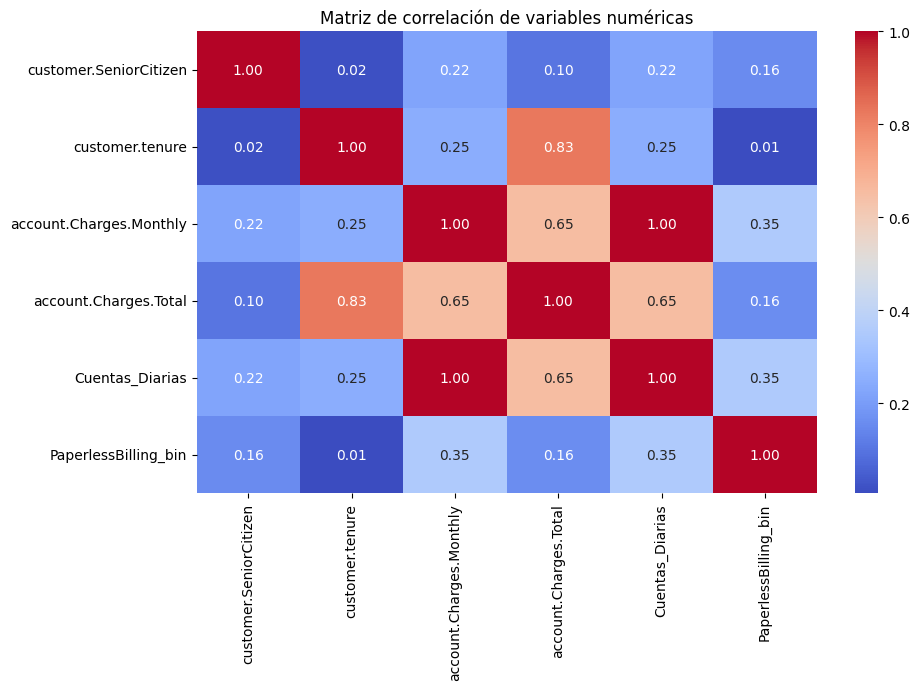

In [16]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación de variables numéricas")
plt.show()

# Observaciones

Tras el estudio de las variables numéricas frente a la deserción (Churn), se determinaron las siguientes dinámicas estadísticas:



*   Relación Inversa de la Fidelidad (customer.tenure): Se identificó una correlación negativa moderada respecto a la variable Churn_bin. Estadísticamente, esto confirma que la estabilidad del cliente aumenta con la antigüedad; a mayor tiempo de permanencia, menor es la propensión al abandono.
*   Impacto del Valor Acumulado (account.Charges.Total): El gasto total acumulado también exhibe una correlación negativa con la cancelación. Este comportamiento es consistente con la variable de antigüedad, sugiriendo que los clientes de "alto valor histórico" son los más leales a la compañía.


*   Sensibilidad al Costo Operativo (account.Charges.Monthly): A diferencia de los cargos totales, el gasto mensual presenta una correlación positiva leve. Esto indica que incrementos o montos elevados en la facturación corriente actúan como un factor de fricción que eleva ligeramente el riesgo de salida.
*  Naturaleza Multidimensional del Fenómeno: Un hallazgo crítico es la ausencia de una única variable con correlación dominante (extrema). Esto implica que la decisión de cancelación no responde a un solo motivo, sino a una interacción compleja de múltiples factores, lo que justifica el uso de modelos predictivos avanzados en lugar de análisis lineales simples.







# Análisis dirigido
Se analíza cómo variables específicas se relacionan con la cancelación de clientes.

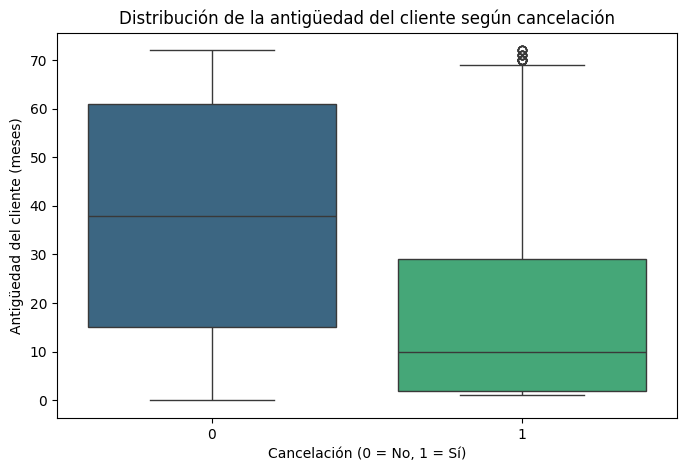

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Churn_bin",
    y="customer.tenure",
    data=df_ml,
    hue="Churn_bin",
    palette="viridis",
    legend=False
)
plt.title("Distribución de la antigüedad del cliente según cancelación")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Antigüedad del cliente (meses)")
plt.show()

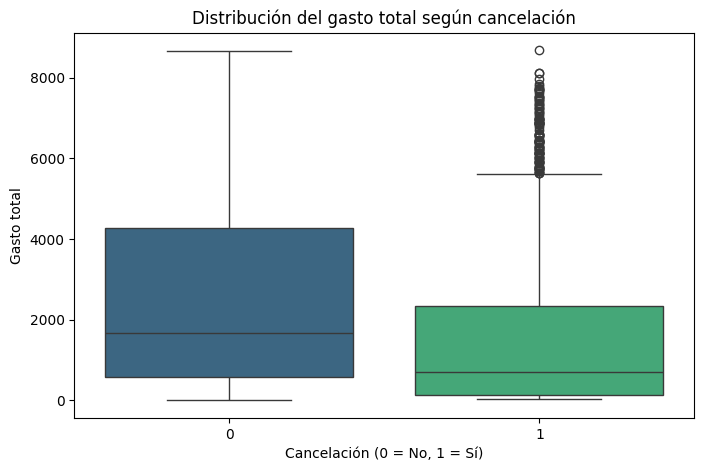

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Churn_bin",
    y="account.Charges.Total",
    data=df_ml,
    hue="Churn_bin",
    palette="viridis",
    legend=False
)
plt.title("Distribución del gasto total según cancelación")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Gasto total")
plt.show()

# Síntesis de Hallazgos

Tras el análisis comparativo entre los segmentos de clientes activos y aquellos en estado de deserción, se extraen las siguientes conclusiones fundamentales:

* Brecha de Fidelidad Cronológica: Se evidencia una disparidad crítica en la antigüedad; los clientes que rescinden el contrato presentan un tiempo de permanencia significativamente inferior al promedio de la cartera activa. Esto sitúa a los clientes nuevos en una zona de riesgo operativo que requiere atención inmediata.

* Correlación entre Permanencia y Capitalización: El gasto acumulado (Total Charges) de los clientes que abandonan es notablemente bajo. Este dato no es aislado, sino que refuerza la tesis de que la deserción ocurre antes de que el cliente alcance su punto de maduración y rentabilidad óptima para la empresa.

* Maximización del LTV (Lifetime Value): Se confirma que la estabilidad contractual a largo plazo es el motor de valor del negocio. Los clientes con mayor trayectoria no solo representan una fuente de ingresos superior y constante, sino que exhiben una resistencia orgánica frente a la competencia, consolidándose como el segmento de menor propensión al churn.

#Separación de datos de entrenamiento

In [9]:
# Se definen variables predictoras y variable objetivo
X = df_ml.drop(columns=["Churn_bin"])
y = df_ml["Churn_bin"]



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

#Encoding y preprocesamiento de los datos

In [10]:
# Columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

categorical_cols, numeric_cols

(Index(['customer.gender', 'customer.Partner', 'customer.Dependents',
        'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
        'internet.OnlineSecurity', 'internet.OnlineBackup',
        'internet.DeviceProtection', 'internet.TechSupport',
        'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
        'account.PaperlessBilling', 'account.PaymentMethod'],
       dtype='object'),
 Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly',
        'account.Charges.Total', 'Cuentas_Diarias', 'PaperlessBilling_bin'],
       dtype='object'))

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

In [12]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((4930, 42), (2113, 42))

In [13]:
("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_cols),
("num", "passthrough", numeric_cols)

('num',
 'passthrough',
 Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly',
        'account.Charges.Total', 'Cuentas_Diarias', 'PaperlessBilling_bin'],
       dtype='object'))

In [14]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((4930, 42), (2113, 42))

Mediante el método one-hot encoding, el proceso generó un conjunto de datos con 42 variables finales (combinando variables numéricas y categóricas)

# Creación de modelos predictivos

In [23]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_processed, y_train)

y_pred_dummy = dummy.predict(X_test_processed)

# 1) Regresión Logística

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("scaler", MinMaxScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)

# 2) Árbol de Decisión

In [25]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_processed, y_train)

y_pred_dt = dt.predict(X_test_processed)

# Evaluación de modelos

In [26]:
def evaluar_modelo(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }


resultados = {
    "Baseline (Dummy)": evaluar_modelo(y_test, y_pred_dummy),
    "Árbol de Decisión": evaluar_modelo(y_test, y_pred_dt),
    "Regresión Logística": evaluar_modelo(y_test, y_pred_logreg)
}

resultados_df = pd.DataFrame(resultados).T
resultados_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Accuracy,Precision,Recall,F1-score
Baseline (Dummy),0.734501,0.000000,0.000000,0.000000
Árbol de Decisión,0.728822,0.489899,0.518717,0.503896
Regresión Logística,0.796971,0.639831,0.538324,0.584705


# Evaluación y Selección del Modelo Predictivo
Tras la implementación y testeo de diversos algoritmos de clasificación, se presentan las siguientes conclusiones técnicas:

* Ineficiencia del Modelo Baseline: Aunque el modelo base muestra una métrica de accuracy (exactitud) engañosamente alta, este resultado es un sesgo derivado del desbalanceo de clases en el dataset. En la práctica, el modelo falla en su objetivo principal: es incapaz de identificar a los clientes con intención de cancelación, clasificando erróneamente a la mayoría como activos.

* Capacidad Detectora del Árbol de Decisión: La implementación del Árbol de Decisión permitió una mejora sustancial en la sensibilidad (recall) del modelo, logrando capturar un mayor volumen de casos reales de churn. No obstante, este incremento en la detección conlleva un costo en la precisión, generando un número superior de falsos positivos.

* Optimización y Equilibrio con Regresión Logística: La Regresión Logística se consolida como la solución óptima para este desafío. Este modelo logra el balance más robusto entre precisión y recall, reflejado en un F1-score superior. Por su capacidad para minimizar errores de clasificación en ambos sentidos, se selecciona como el modelo de mejor desempeño general para la estrategia de retención de Telecom X.

# Matriz de confusión

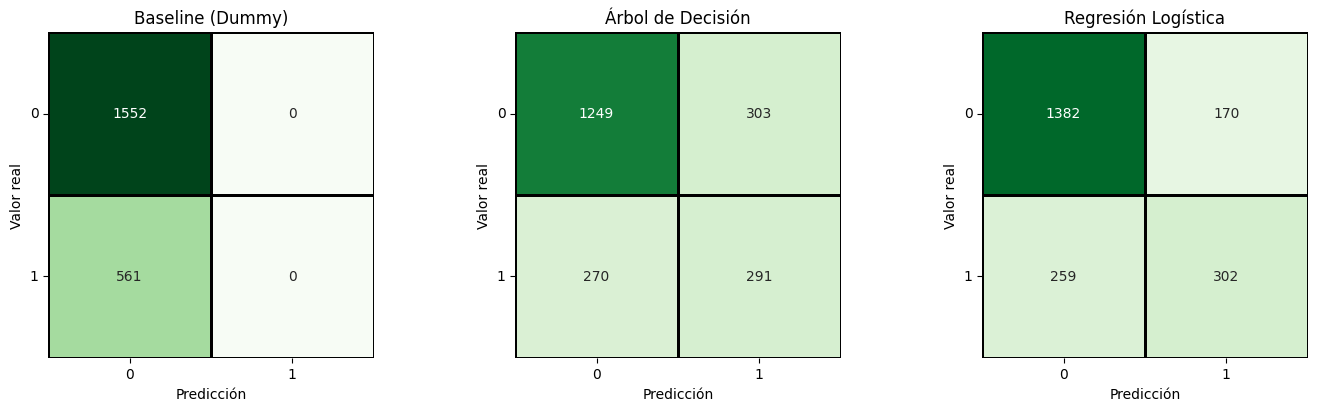

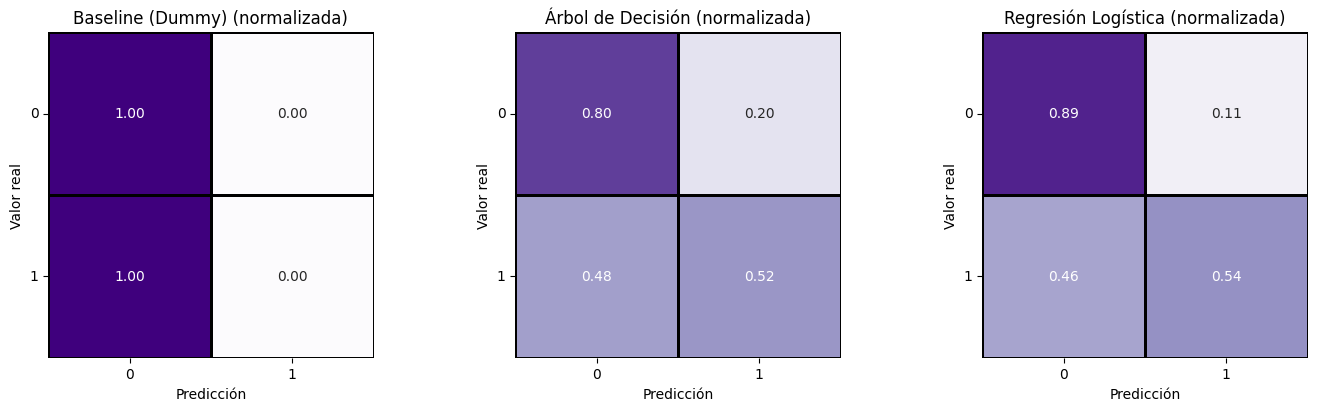

In [36]:
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

cms = [cm_dummy, cm_dt, cm_logreg]
titulos = ["Baseline (Dummy)", "Árbol de Decisión", "Regresión Logística"]

# CONTEOS ABSOLUTOS — escala común
vmax = max(cm.max() for cm in cms)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for ax, cm, titulo in zip(axes, cms, titulos):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        vmin=0,
        vmax=vmax,
        cbar=False,
        square=True,
        linewidths=0.8,
        linecolor="black",
        ax=ax
    )
    ax.set_title(titulo)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"], rotation=0)

plt.show()

# Matrices por fila
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for ax, cm, titulo in zip(axes, cms, titulos):
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Purples",
        vmin=0,
        vmax=1,
        cbar=False,
        square=True,
        linewidths=0.8,
        linecolor="black",
        ax=ax
    )
    ax.set_title(f"{titulo} (normalizada)")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"], rotation=0)

plt.show()

Para una auditoría detallada del rendimiento de los modelos, se emplearon matrices de confusión presentadas bajo dos enfoques complementarios:

* Valores Absolutos: Permiten cuantificar el volumen exacto de predicciones correctas e incorrectas (Verdaderos Positivos, Falsos Negativos, etc.), proporcionando una visión clara del impacto operativo de cada modelo.

* Normalización por Filas: Este tratamiento de los datos facilita un comparativo objetivo del desempeño, eliminando el sesgo visual del desbalance de clases. Al normalizar, es posible evaluar con precisión la tasa de detección de cancelaciones (Recall) frente a la permanencia de clientes, permitiendo una validación cruzada entre los diferentes algoritmos de forma estandarizada.

# Importancia de la variables
Se realiza el análisis de las variables más relevantes para la predicción de la cancelación de clientes

In [37]:
# Se obtienen los nombres de las variables luego del Encoding
ohe = preprocessor.named_transformers_["cat"]
encoded_cat_cols = ohe.get_feature_names_out(categorical_cols)

# Unimos categóricas codificadas + numéricas
feature_names = np.concatenate([encoded_cat_cols, numeric_cols])

len(feature_names)

42

In [38]:
# Extracción de coeficientes de la regresión logística
coeficientes = logreg_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coeficientes
})

coef_df.head()

,Variable,Coeficiente
0,customer.gender_Male,-0.086402
1,customer.Partner_Yes,-0.032902
2,customer.Dependents_Yes,-0.202550
3,phone.PhoneService_Yes,-0.220971
4,phone.MultipleLines_No,-0.246190


In [39]:
# Variables que aumentan la probabilidad de churn
top_positive = coef_df.sort_values("Coeficiente", ascending=False).head(10)
top_positive

,Variable,Coeficiente
39,account.Charges.Total,1.256297
28,account.Contract_Month-to-month,0.633932
8,internet.InternetService_Fiber optic,0.401710
34,account.PaymentMethod_Electronic check,0.245238
41,PaperlessBilling_bin,0.203393
31,account.PaperlessBilling_Yes,0.203393
19,internet.TechSupport_No,0.189754
36,customer.SeniorCitizen,0.166790
10,internet.OnlineSecurity_No,0.136302
24,internet.StreamingTV_Yes,0.108010


In [41]:
# Variables que reducen la probabilidad de cancelación
top_negative = coef_df.sort_values("Coeficiente").head(10)
top_negative

,Variable,Coeficiente
37,customer.tenure,-3.207906
30,account.Contract_Two year,-0.684750
7,internet.InternetService_DSL,-0.423110
4,phone.MultipleLines_No,-0.246190
3,phone.PhoneService_Yes,-0.220971
21,internet.TechSupport_Yes,-0.211154
2,customer.Dependents_Yes,-0.202550
33,account.PaymentMethod_Credit card (automatic),-0.199242
17,internet.DeviceProtection_No internet service,-0.157717
20,internet.TechSupport_No internet service,-0.157717


# Variables más influyentes

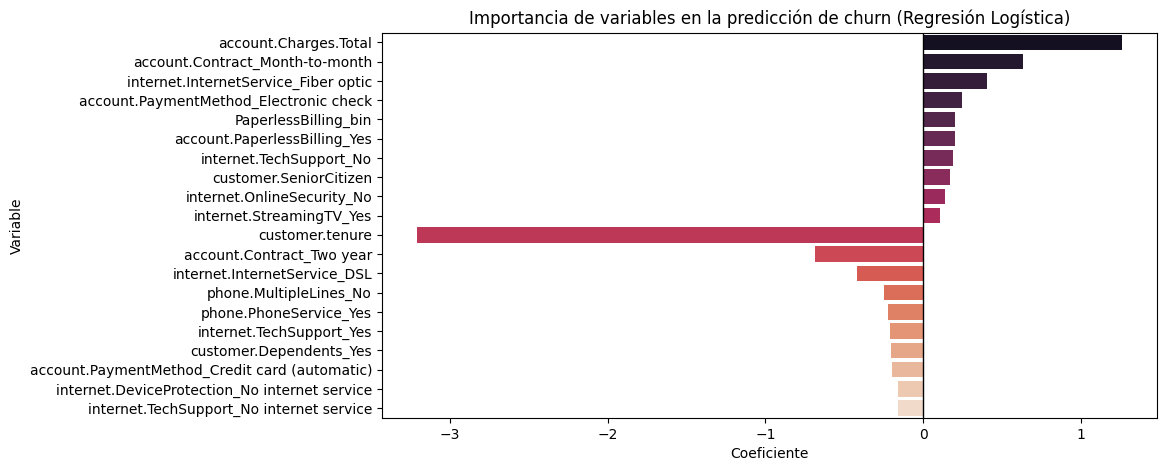

In [46]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=pd.concat([top_positive, top_negative]),
    x="Coeficiente",
    y="Variable",
    hue="Variable",
    palette="rocket",
    legend=False
)

plt.title("Importancia de variables en la predicción de churn (Regresión Logística)")
plt.axvline(0, color="black", linewidth=1)
plt.show()

# 🏁 Conclusión General: Estrategia de Retención Basada en Datos
El presente proyecto de Ciencia de Datos se centró en el diseño y validación de un ecosistema predictivo para identificar el riesgo de deserción (churn) en Telecom X. A través de un proceso riguroso de ingeniería de características, análisis exploratorio y entrenamiento de modelos, se transformaron datos crudos en inteligencia de negocios accionable.

# 🔬 Evaluación y Selección Técnica
Dada la naturaleza del desbalance de clases en el sector de telecomunicaciones, la evaluación no se limitó a la exactitud global, sino que priorizó el Recall y el F1-Score.

* Liderazgo de la Regresión Logística: Este modelo se consolidó como la solución óptima, ofreciendo el equilibrio más robusto entre la detección proactiva de cancelaciones y la precisión de las alertas generadas.

* Interpretatibilidad del Árbol de Decisión: Aunque mostró un desempeño competitivo, su principal valor reside en la transparencia de sus reglas de decisión.

* Sesgo del Baseline: El análisis confirmó que métricas simplistas como la accuracy son insuficientes y riesgosas en problemas de clasificación de churn.

# 💡 Factores Determinantes del Abandono
El modelo permitió aislar las variables con mayor peso estadístico. El perfil de riesgo se concentra en:

* Temporalidad Crítica: Clientes con baja antigüedad y contratos de corto plazo (mes a mes).

* Configuración de Servicios: Usuarios con baja vinculación multiproducto.
Por el contrario, la fidelidad cronológica y los contratos de larga duración actúan como las barreras más fuertes contra la competencia.

# 🛠️ Hoja de Ruta Estratégica
Para capitalizar estos hallazgos, se proponen las siguientes acciones inmediatas para Telecom X:

* Blindaje de Clientes Nuevos: Ejecutar protocolos de fidelización intensiva durante el "periodo crítico" (primeros meses de contrato).

* Optimización del Mix de Productos: Incentivar la contratación de servicios combinados (bundling) para elevar el costo de cambio y el valor percibido.

* Sistema de Alerta Temprana (EWS): Integrar el modelo de Regresión Logística en el flujo operativo para disparar acciones preventivas automatizadas antes de que la cancelación se materialice.

# 📐 Justificación de Arquitectura de Modelos
En cuanto a la selección de algoritmos, se optó por descartar métodos basados en distancia como K-Nearest Neighbors (KNN). Debido a la alta dimensionalidad generada tras la codificación de variables (encoding), la Regresión Logística y los modelos basados en Árboles demostraron una superioridad técnica en términos de interpretabilidad, eficiencia computacional y alineación con los objetivos de negocio.